# 00 — Data inspection

Inspect raw ECG data. Implement `load_raw_dataset()` in `src/data/io.py` before running the load cell.

## Setup

Configure logging and ensure the notebook imports code from this project (not another copy elsewhere on the system).

In [ ]:
from pathlib import Path
import sys
from src.data.io import load_raw_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

# Project root = parent of notebooks/
PROJECT_ROOT = Path.cwd().resolve().parents[0]

# Make sure our repo root is searched FIRST
project_root_str = str(PROJECT_ROOT)
if project_root_str in sys.path:
    sys.path.remove(project_root_str)
sys.path.insert(0, project_root_str)

print("Using PROJECT_ROOT:", PROJECT_ROOT)
print("sys.path[0]:", sys.path[0])

import src.data.io as io
from src.data.io import load_raw_dataset

print("src.data.io file:", io.__file__)

Using PROJECT_ROOT: C:\Projects\DeepLearningProject
sys.path[0]: C:\Projects\DeepLearningProject
src.data.io file: C:\Projects\DeepLearningProject\src\data\io.py


## Load data (rebuild cache)

Load the ECG dataset from the raw WFDB files, deleting any existing cache and rebuilding it from scratch. This step parses all recordings, constructs the signal and label arrays, and saves a new cached copy for faster future loading. The printed shapes confirm that the data loaded successfully and match the expected dimensions.

In [ ]:
X, y = load_raw_dataset(force_reload = False)

print("X shape:", X.shape)
print("y shape:", y.shape)

2026-02-27 01:05:51,510 | WARNING | force_reload=True — removing cached dataset: C:\Projects\DeepLearningProject\data\processed\chapman_wfdb_Xy.npz
2026-02-27 01:05:51,837 | INFO | Stage 1/4 — Loading raw WFDB files (45152 records)
2026-02-27 01:06:06,421 | INFO | Loading progress 4516/45152 (10%) | 310 rec/s | ETA 131s | kept 4515
2026-02-27 01:06:11,654 | INFO | Loading progress 9031/45152 (20%) | 456 rec/s | ETA 79s | kept 9030
2026-02-27 01:06:16,736 | INFO | Loading progress 13546/45152 (30%) | 544 rec/s | ETA 58s | kept 13545
2026-02-27 01:06:21,881 | INFO | Loading progress 18061/45152 (40%) | 601 rec/s | ETA 45s | kept 18060
2026-02-27 01:06:27,140 | INFO | Loading progress 22576/45152 (50%) | 639 rec/s | ETA 35s | kept 22575
2026-02-27 01:06:32,400 | INFO | Loading progress 27092/45152 (60%) | 668 rec/s | ETA 27s | kept 27090
2026-02-27 01:06:37,562 | INFO | Loading progress 31607/45152 (70%) | 691 rec/s | ETA 20s | kept 31605
2026-02-27 01:06:42,913 | INFO | Loading progress 

X shape: (45150, 12, 5000)
y shape: (45150, 4)


# Exploration


In [17]:
CLASS_NAMES = [
    "Atrial\nFibrillation",
    "Supraventricular\nTachycardia",
    "Sinus\nBradycardia",
    "Sinus\nRhythm",
]

## Dataset overview

Report the basic structure of the dataset, including the number of recordings, number of ECG leads, samples per recording, and approximate signal duration (assuming a 500 Hz sampling rate).

In [7]:
N, n_leads, T = X.shape

print(f"Recordings: {N}")
print(f"Leads: {n_leads}")
print(f"Samples per lead: {T}")
print(f"Duration @500 Hz: {T/500:.2f} sec")

Recordings: 45150
Leads: 12
Samples per lead: 5000
Duration @500 Hz: 10.00 sec


## Label distribution

Compute the number of recordings associated with each target class to assess class balance and identify any heavily under- or over-represented diagnoses.

In [ ]:
class_counts = y.sum(axis=0)
counts = pd.Series(class_counts)

counts

0     1780
1     1091
2    16559
3     8125
dtype: int32

## Class distribution (visual)

Visualize the number of recordings in each target class using a bar chart to highlight class imbalance and relative prevalence across diagnoses.

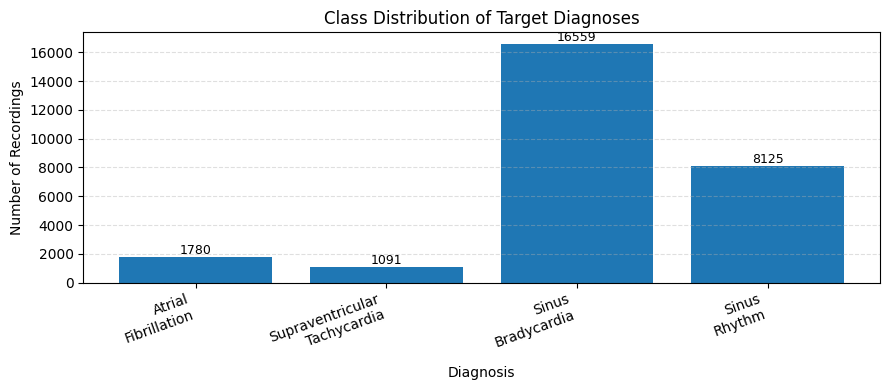

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(CLASS_NAMES, counts.values)

ax.set_title("Class Distribution of Target Diagnoses")
ax.set_ylabel("Number of Recordings")
ax.set_xlabel("Diagnosis")

ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## Label co-occurrence

Compute and visualize how often pairs of diagnoses appear together across recordings, providing insight into relationships between classes in this multilabel dataset.

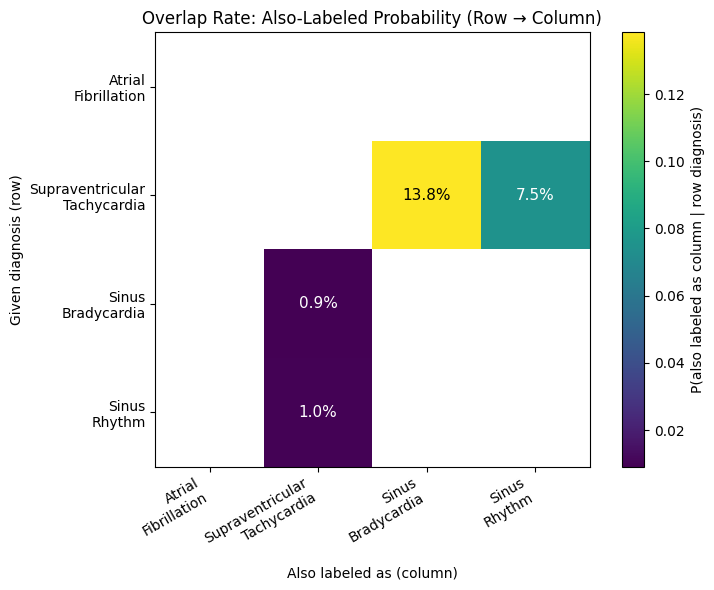

In [54]:
co_occurrence = y.astype(np.int32).T @ y.astype(np.int32)

diag = co_occurrence.diagonal()
cond = co_occurrence / diag[:, None]  # P(column | row)

M = cond.copy()
np.fill_diagonal(M, np.nan)
M[M < 0.005] = np.nan  # hide tiny overlaps (<0.5%)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(M, aspect="equal")

ax.set_title("Overlap Rate: Also-Labeled Probability (Row → Column)")
ax.set_xlabel("Also labeled as (column)")
ax.set_ylabel("Given diagnosis (row)")

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_yticklabels(CLASS_NAMES)

# Auto-contrast based on the *rendered* cell color (RGBA luminance)
# This matches what you actually see on screen.
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        val = M[i, j]
        if np.isnan(val):
            continue

        rgba = im.cmap(im.norm(val))
        r, g, b, _ = rgba
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b  # perceived brightness
        txt_color = "black" if luminance > 0.6 else "white"

        ax.text(
            j, i, f"{val:.1%}",
            ha="center", va="center",
            fontsize=11,
            color=txt_color
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("P(also labeled as column | row diagnosis)")

plt.tight_layout()
plt.show()

## Example signals

Display one randomly selected recording across all leads to visually confirm that the waveforms appear physiologically plausible and correctly aligned.

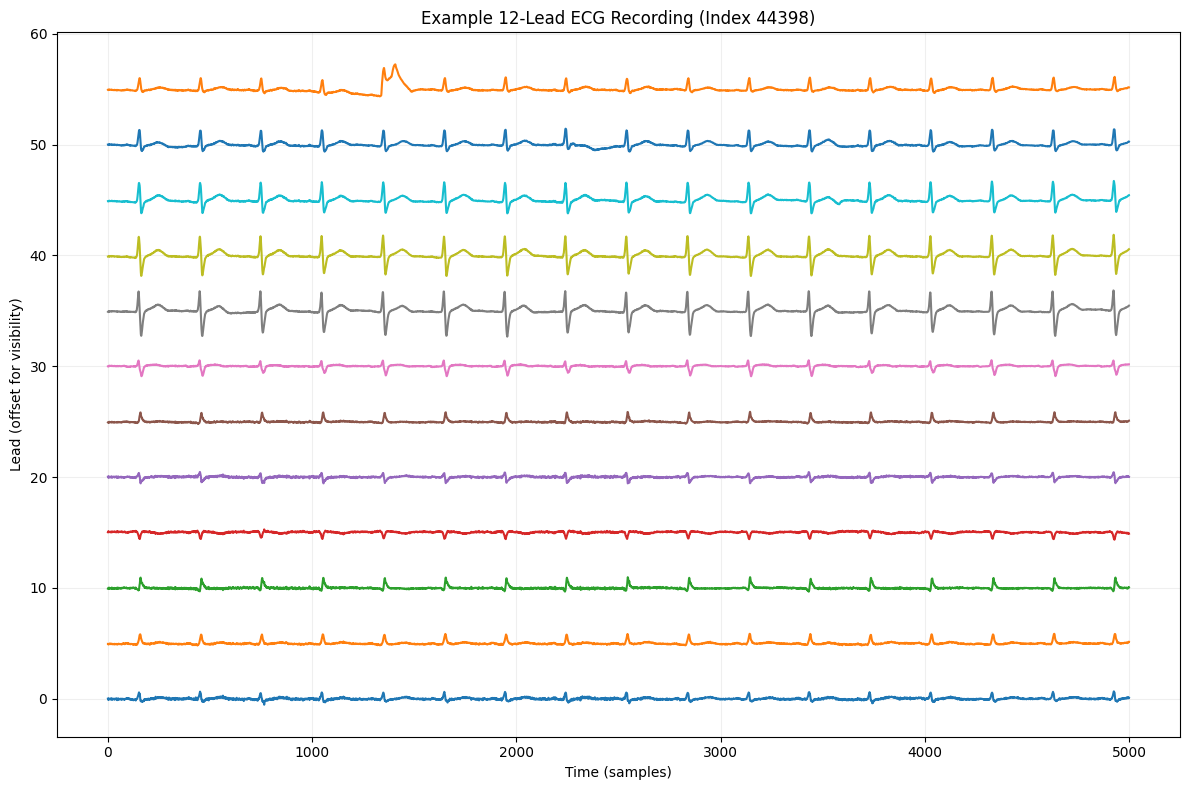

In [40]:
idx = np.random.randint(0, N)
sample = X[idx]

plt.figure(figsize=(12, 8))

offset = 5

for i in range(n_leads):
    plt.plot(sample[i] + i * offset)

plt.title(f"Example 12-Lead ECG Recording (Index {idx})")
plt.xlabel("Time (samples)")
plt.ylabel("Lead (offset for visibility)")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()